In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.getcwd())

from Train_validate import Train_Validate_CNN
from evaluate import Test_model_accuracy_original, Output_Test_Error_Samples
from Bcolors import bcolors
import torch
import matplotlib.pyplot as plt
import numpy as np
from gfanc._paths import MODELS_DIR, SYNTHESIZED_DATASET_DIR, FIGURES_DIR

 
print("GPU 数量:", torch.cuda.device_count())

GPU 数量: 1


In [ ]:
# 训练和验证一个新的 1D-CNN 模型

Folder_name_list_of_data_set=[
   SYNTHESIZED_DATASET_DIR / 'Training_data', 
    SYNTHESIZED_DATASET_DIR / 'Validate_data', 
    SYNTHESIZED_DATASET_DIR / 'Testing_data'
]
MODEL_PTH = MODELS_DIR / 'MIMO_M5_res_Synthetic.pth'
File_sheet = 'Hard_Index_band_power.csv' 

acc_train, acc_validate, train_loss_epochs, validate_loss_epochs = Train_Validate_CNN(
                                                            TRAIN_DATASET_FILE =Folder_name_list_of_data_set[0], 
                                                            VALIDATION_DATASET_FILE=Folder_name_list_of_data_set[1], 
                                                            MODEL_PTH=MODEL_PTH, File_sheet=File_sheet)

模型最后一层: Linear(in_features=256, out_features=30, bias=True)

第 1/50 轮
学习率: 0.010000
训练损失: 0.0926  bit准确率: 0.9611  扬声器准确率: 0.6138
验证损失: 0.0719  bit准确率: 0.9704  扬声器准确率: 0.6495
最佳模型已保存至 D:\VSCodeRepository\MIMO_GFANC\models\MIMO_M6_res_Synthetic.pth
----------------------------------------

第 2/50 轮
学习率: 0.010000
训练损失: 0.0267  bit准确率: 0.9900  扬声器准确率: 0.8567
验证损失: 0.0600  bit准确率: 0.9785  扬声器准确率: 0.6975
最佳模型已保存至 D:\VSCodeRepository\MIMO_GFANC\models\MIMO_M6_res_Synthetic.pth
----------------------------------------

第 3/50 轮
学习率: 0.010000
训练损失: 0.0175  bit准确率: 0.9939  扬声器准确率: 0.9108
验证损失: 0.0149  bit准确率: 0.9940  扬声器准确率: 0.9105
最佳模型已保存至 D:\VSCodeRepository\MIMO_GFANC\models\MIMO_M6_res_Synthetic.pth
----------------------------------------

第 4/50 轮
学习率: 0.010000
训练损失: 0.0151  bit准确率: 0.9947  扬声器准确率: 0.9225
验证损失: 0.0126  bit准确率: 0.9953  扬声器准确率: 0.9300
最佳模型已保存至 D:\VSCodeRepository\MIMO_GFANC\models\MIMO_M6_res_Synthetic.pth
----------------------------------------

第 5/50 轮
学习率: 0.010000
训练损失

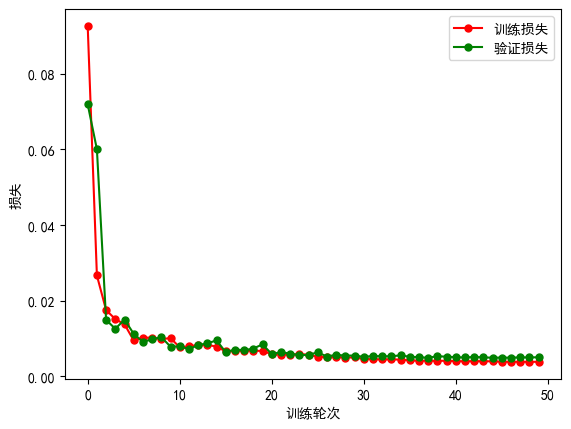

In [3]:
# 设置中文字体，避免乱码
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']  # 指定默认字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号 '-' 显示为方块的问题

plt.plot(np.arange(len(train_loss_epochs)),train_loss_epochs, marker='.', markersize=10, color='r',label='训练损失')
plt.plot(np.arange(len(validate_loss_epochs)),validate_loss_epochs, marker='.', markersize=10, color='g',label='验证损失')
plt.ylabel('损失')
plt.xlabel('训练轮次')
plt.legend()
plt.savefig(FIGURES_DIR / 'Training_loss.png', dpi=600, bbox_inches='tight', pad_inches=0)

plt.show()

In [4]:
# 在测试数据集上测试训练好的 CNN 模型

MODEL_PTH = MODELS_DIR / 'MIMO_M6_res_Synthetic.pth'

Folder_name_list_of_data_set=[
    SYNTHESIZED_DATASET_DIR / 'Training_data', 
    SYNTHESIZED_DATASET_DIR / 'Validate_data', 
    SYNTHESIZED_DATASET_DIR / 'Testing_data'
]
File_sheet = 'Hard_Index_band_power.csv'
if os.path.exists(MODEL_PTH):
    acc = Test_model_accuracy_original(TESTING_DATASET_FILE=Folder_name_list_of_data_set[2]
                                      , MODLE_PTH=MODEL_PTH, File_sheet=File_sheet)
    repot = bcolors.OKGREEN  + f' 测试数据集准确率为 {acc}' + bcolors.ENDC
    print(repot)
else:
    print(bcolors.FAIL + MODEL_PTH + ' 不存在 !' + bcolors.ENDC)

 测试数据集准确率为 0.9645000000000004


In [5]:
# 输出预训练网络的测试错误样本

MODEL_PTH = MODELS_DIR / 'MIMO_M6_res_Synthetic.pth'

Folder_name_list_of_data_set=[
    SYNTHESIZED_DATASET_DIR / 'Training_data', 
    SYNTHESIZED_DATASET_DIR / 'Validate_data', 
    SYNTHESIZED_DATASET_DIR / 'Testing_data'
]
File_sheet = 'Hard_Index_band_power.csv'
if os.path.exists(MODEL_PTH):
    acc = Output_Test_Error_Samples(TESTING_DATASET_FILE=Folder_name_list_of_data_set[2]
                                      , MODLE_PTH=MODEL_PTH, File_sheet=File_sheet)
    repot = bcolors.OKGREEN  + f' 测试数据集准确率为 {acc}' + bcolors.ENDC
    print(repot)
else:
    print(bcolors.FAIL + MODEL_PTH + ' 不存在 !' + bcolors.ENDC)

测试数据集长度：2000
差异样本 -> 路径: 1010_Frequency_from_876_to_1134_Hz.wav, 错 2/30 bit, 预测: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 标签: [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
差异样本 -> 路径: 1034_Frequency_from_1755_to_4938_Hz.wav, 错 2/30 bit, 预测: [0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0], 标签: [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
差异样本 -> 路径: 1069_Frequency_from_1991_to_7323_Hz.wav, 错 2/30 bit, 预测: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0], 标签: [0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
差异样本 -> 路径: 108_Frequency_from_3057_to_4139_Hz.wav, 错 2/30 bit, 预测: [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], 标签: [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0